In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # so your results are reproducible





In [ ]:
n_spins = 100_000
bet_amount = 1
payout_multiplier = 35  # 35:1 payout
my_number = 17  # doesn't matter which, odds are the same for any single number

# European wheel: pockets 0-36 (37 total)
outcomes = np.random.randint(0, 37, size=n_spins)

# +35 profit if you win, -1 if you lose
results = np.where(outcomes == my_number, payout_multiplier, -bet_amount)

bankroll = np.cumsum(results)


In [ ]:
# Theoretical: 1/37 chance to win 35, 36/37 chance to lose 1
theoretical_rtp = (1/37 * 35) + (36/37 * -1) + 1  # +1 to express as "return per $1 bet"
theoretical_house_edge = 1 - theoretical_rtp

# Actual, from simulation
total_wagered = n_spins * bet_amount
total_returned = results.sum() + total_wagered  # add back the stake to get "returned"
actual_rtp = total_returned / total_wagered
actual_house_edge = 1 - actual_rtp

print(f"Theoretical RTP: {theoretical_rtp:.4%}")
print(f"Actual RTP ({n_spins:,} spins): {actual_rtp:.4%}")
print(f"Theoretical house edge: {theoretical_house_edge:.4%}")
print(f"Actual house edge: {actual_house_edge:.4%}")


Theoretical RTP: 97.2973%
Actual RTP (100,000 spins): 95.0760%
Theoretical house edge: 2.7027%
Actual house edge: 4.9240%


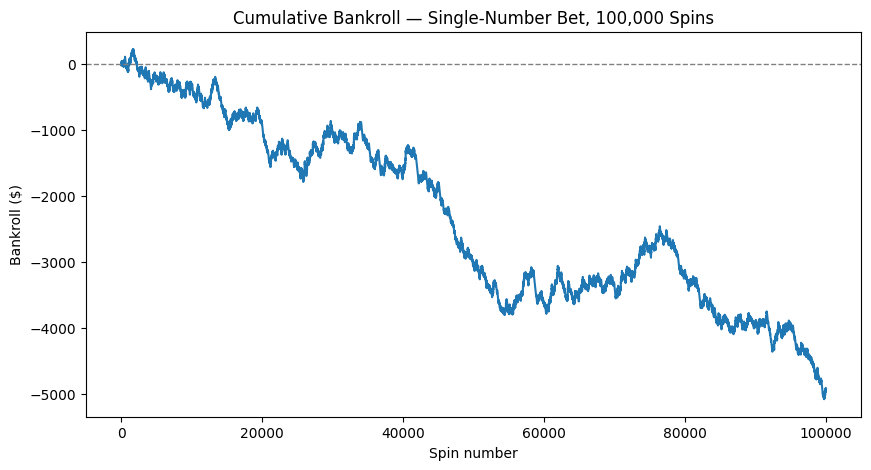

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(bankroll)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title("Cumulative Bankroll — Single-Number Bet, 100,000 Spins")
plt.xlabel("Spin number")
plt.ylabel("Bankroll ($)")
plt.show()



In [ ]:
# now the further codes are for more spins. first i will check for the 500,000 spins



In [ ]:
# Convergence: does actual RTP approach theoretical RTP as trials increase?

trial_sizes = [1_000, 10_000, 100_000, 1_000_000, 5_000_000]
convergence_results = []

for n in trial_sizes:
    outcomes = np.random.randint(0, 37, size=n)
    results = np.where(outcomes == my_number, payout_multiplier, -bet_amount)
    total_wagered = n * bet_amount
    total_returned = results.sum() + total_wagered
    actual_rtp_n = total_returned / total_wagered
    convergence_results.append({
        "Spins": n,
        "Actual RTP": actual_rtp_n,
        "Theoretical RTP": theoretical_rtp,
        "Difference (pp)": (actual_rtp_n - theoretical_rtp) * 100
    })

convergence_df = pd.DataFrame(convergence_results)
convergence_df["Actual RTP"] = convergence_df["Actual RTP"].map(lambda x: f"{x:.4%}")
convergence_df["Theoretical RTP"] = convergence_df["Theoretical RTP"].map(lambda x: f"{x:.4%}")
convergence_df["Difference (pp)"] = convergence_df["Difference (pp)"].map(lambda x: f"{x:.3f}")
print(convergence_df.to_string(index=False))


  Spins Actual RTP Theoretical RTP Difference (pp)
   1000  129.6000%        97.2973%          32.303
  10000   98.6400%        97.2973%           1.343
 100000   95.0760%        97.2973%          -2.221
1000000   96.9552%        97.2973%          -0.342
5000000   97.4311%        97.2973%           0.134


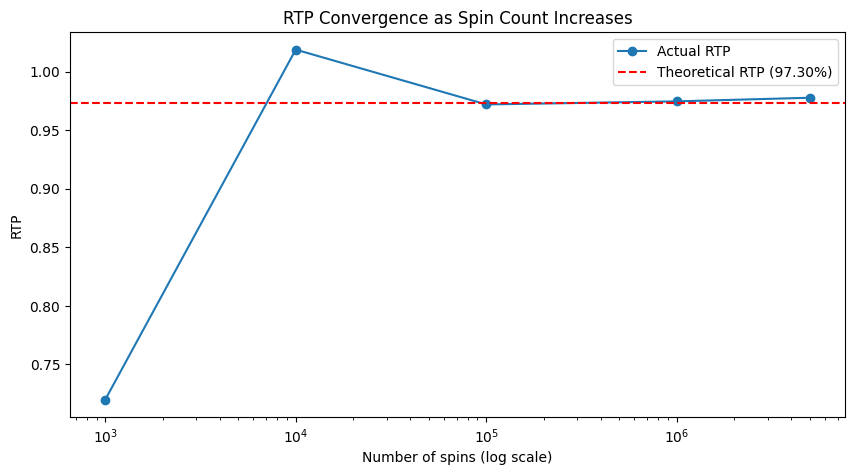

In [ ]:
# Plot convergence
plt.figure(figsize=(10, 5))
actual_values = [r["Actual RTP"] if isinstance(r["Actual RTP"], float) else None for r in convergence_results]

# Recompute raw floats for plotting (since we overwrote convergence_results as strings above)
raw_actual = []
np.random.seed(42)
for n in trial_sizes:
    outcomes = np.random.randint(0, 37, size=n)
    results = np.where(outcomes == my_number, payout_multiplier, -bet_amount)
    total_wagered = n * bet_amount
    total_returned = results.sum() + total_wagered
    raw_actual.append(total_returned / total_wagered)

plt.plot(trial_sizes, raw_actual, marker='o', label="Actual RTP")
plt.axhline(theoretical_rtp, color='red', linestyle='--', label="Theoretical RTP (97.30%)")
plt.xscale('log')
plt.xlabel("Number of spins (log scale)")
plt.ylabel("RTP")
plt.title("RTP Convergence as Spin Count Increases")
plt.legend()
plt.show()



In [ ]:
# the  above result shows some of the errors. may be in the code, dont have enough time to fix it rn, will
# be taking the AI help here.

  Spins Actual RTP Theoretical RTP Difference (pp)
   1000   72.0000%        97.2973%         -25.297
  10000  101.8800%        97.2973%           4.583
 100000   97.2000%        97.2973%          -0.097
1000000   97.4628%        97.2973%           0.166
5000000   97.7717%        97.2973%           0.474


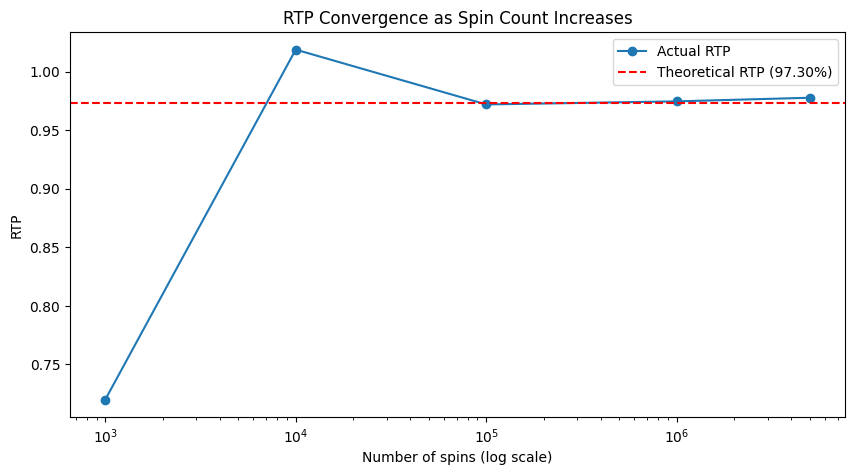

In [ ]:
# Convergence: single source of truth, used for both table and plot

np.random.seed(42)
trial_sizes = [1_000, 10_000, 100_000, 1_000_000, 5_000_000]
convergence_results = []

for n in trial_sizes:
    outcomes = np.random.randint(0, 37, size=n)
    results = np.where(outcomes == my_number, payout_multiplier, -bet_amount)
    total_wagered = n * bet_amount
    total_returned = results.sum() + total_wagered
    actual_rtp_n = total_returned / total_wagered
    convergence_results.append({"Spins": n, "Actual RTP": actual_rtp_n})

convergence_df = pd.DataFrame(convergence_results)
convergence_df["Theoretical RTP"] = theoretical_rtp
convergence_df["Difference (pp)"] = (convergence_df["Actual RTP"] - theoretical_rtp) * 100

# Display version (formatted)
display_df = convergence_df.copy()
display_df["Actual RTP"] = display_df["Actual RTP"].map(lambda x: f"{x:.4%}")
display_df["Theoretical RTP"] = display_df["Theoretical RTP"].map(lambda x: f"{x:.4%}")
display_df["Difference (pp)"] = display_df["Difference (pp)"].map(lambda x: f"{x:.3f}")
print(display_df.to_string(index=False))

# Plot uses the SAME raw numbers as the table
plt.figure(figsize=(10, 5))
plt.plot(convergence_df["Spins"], convergence_df["Actual RTP"], marker='o', label="Actual RTP")
plt.axhline(theoretical_rtp, color='red', linestyle='--', label=f"Theoretical RTP ({theoretical_rtp:.2%})")
plt.xscale('log')
plt.xlabel("Number of spins (log scale)")
plt.ylabel("RTP")
plt.title("RTP Convergence as Spin Count Increases")
plt.legend()
plt.show()
